# Notebook 05.1 — Índice de Acessibilidade AE2SFCA

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Autor:** Felipe Ramos Dantas  
**Orientador:** Prof. Dr. Antonio Joaquim da Silva  
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs  
**Apêndice:** H · **Última atualização:** 2026-06-23

---
## Objetivo
Calcular o índice de acessibilidade **AE2SFCA** (areal) por setor censitário, nos modos
automóvel e pedestre, e a versão tradicional **E2SFCA** (centroide) para comparação (H1).
Identificar os setores classificados como "desertos de saúde".

## Entrada
| Arquivo | Origem |
|---|---|
| `intermediarios/05_isocronas/zonaUrbana_5km_isocronas_{carro,pedestre}.parquet` | NB 04.1 |
| `intermediarios/03_ubs/teresina_zonaUrbana_buffer5km_ubs_capacidade.parquet` | NB 01.3 (oferta, 81 UBS) |
| `intermediarios/01_malha/teresina_setoresCensitarios_DadosCompletos.parquet` | NB 01.1 |

## Saída
| Arquivo | Consumido por |
|---|---|
| `processados/teresina_setores_acessibilidade.parquet` | NB 06.1 (testes H1/H2) |
| `outputs/tabelas/nb051/nb051_sintese_indice.csv` | Resultados (5.4) |

---

## 1. Configuração e importações

Bibliotecas, *helpers* do projeto e criação das subpastas de figuras e tabelas (`nb051`).

In [1]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO ───────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import geopandas as gpd

import mapclassify

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from mapeprof.config import (EXT_IBGE, INT_ISOCRONAS, INT_MALHA, INT_UBS, PROCESSADOS,
                             FIGURAS, TABELAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import (aplicar_estilo, barra_escala, seta_norte, moldura_mapa,
                          formatar_eixos_mapa, ajustar_zoom_camada)

aplicar_estilo()
warnings.filterwarnings("ignore")
criar_diretorios()
FIGURAS_NB = FIGURAS / "nb051"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
TABELAS_NB = TABELAS / "nb051"; TABELAS_NB.mkdir(parents=True, exist_ok=True)

FONTE_PADRAO = "CNES/DataSUS; IBGE (2022); Overture Maps Foundation (2026). Elaboração própria."
print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Carga e parâmetros

Carga das isócronas (NB 04.1), dos setores com população (NB 01.1) e da oferta de 81 UBS (NB 01.3); define os pesos de decaimento gaussiano de Luo e Qi (2009).

In [2]:
# ── 2. CARGA E PARÂMETROS ───────────────────────────────────────────────────
gdf_zu        = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
gdf_zu_buffer = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO)

setores = gpd.read_parquet(
    INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet").to_crs(CRS_METRICO)
setores["populacao"]  = pd.to_numeric(setores["populacao"], errors="coerce").fillna(0)  # já vem nomeada
setores["setor_area"] = setores.geometry.area

iso_carro = gpd.read_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_carro.parquet").to_crs(CRS_METRICO)
iso_pe    = gpd.read_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_pedestre.parquet").to_crs(CRS_METRICO)

PESOS = {10: 1.00, 20: 0.68, 30: 0.22}   # decaimento gaussiano (Luo; Qi, 2009)
# Oferta = 81 UBS da área de estudo (75 ZU + 6 borda); mesma base das isócronas
ubs_cap = gpd.read_parquet(INT_UBS / "teresina_zonaUrbana_buffer5km_ubs_capacidade.parquet")
oferta  = ubs_cap.set_index("cnes")["capacidade_equipes"].astype(float)

print(f"Oferta: {len(oferta)} UBS | total {oferta.sum():.0f} equipes | sem equipe: {int((oferta==0).sum())}")
print(f"🔄 {len(setores)} setores | pop {setores['populacao'].sum():,.0f}")

Oferta: 81 UBS | total 474 equipes | sem equipe: 1
🔄 1375 setores | pop 807,660


## 3. Cálculo do AE2SFCA areal

O método tem dois passos. No **Passo 1**, para cada UBS, soma-se a população de demanda
ponderada pela **fração de área** de cada setor contida em cada faixa isócrona e pelo peso
de decaimento da faixa; a razão oferta-demanda é `Rⱼ = Sⱼ / demanda`. No **Passo 2**, a
acessibilidade de cada setor é a soma das razões `Rⱼ` de todas as UBS que o alcançam,
novamente ponderadas pela fração areal e pelo decaimento. A sobreposição areal substitui
a inclusão por centroide, eliminando a premissa de que toda a população reside no centro
do setor.

In [3]:
# ── 3. FUNÇÃO AE2SFCA AREAL ─────────────────────────────────────────────────
def calcular_ae2sfca(isocronas, setores, oferta):
    iso = isocronas.copy()
    iso["w"] = iso["threshold_nominal"].map(PESOS)
    # Michels et.al. descarta provedores com recurso <= 0 (UBS sem equipe sai aqui)
    iso = iso[iso["ubs_id"].isin(oferta[oferta > 0].index)]
    pedacos = gpd.overlay(
        iso[["ubs_id", "w", "geometry"]],
        setores[["CD_SETOR", "populacao", "setor_area", "geometry"]],
        how="intersection", keep_geom_type=False)
    pedacos["frac"] = (pedacos.geometry.area / pedacos["setor_area"]).clip(upper=1.0)  # cap p/ float
    pedacos = pedacos.dropna(subset=["frac"])
    pedacos["pop_pond"] = pedacos["populacao"] * pedacos["frac"] * pedacos["w"]
    demanda = pedacos.groupby("ubs_id")["pop_pond"].sum()
    # S_j por UBS, alinhado à demanda
    Sj = oferta.reindex(demanda.index)
    Rj = (Sj / demanda).replace([np.inf, -np.inf], np.nan).dropna()
    pedacos["contrib"] = pedacos["ubs_id"].map(Rj) * pedacos["w"] * pedacos["frac"]
    return pedacos.groupby("CD_SETOR")["contrib"].sum()


setores["acess_carro"] = setores["CD_SETOR"].map(calcular_ae2sfca(iso_carro, setores, oferta)).fillna(0)
setores["acess_pe"]    = setores["CD_SETOR"].map(calcular_ae2sfca(iso_pe, setores, oferta)).fillna(0)

print(f"✅ AE2SFCA calculado | setores com acesso (carro): {(setores['acess_carro']>0).sum()} | "
      f"(pé): {(setores['acess_pe']>0).sum()}")

✅ AE2SFCA calculado | setores com acesso (carro): 1375 | (pé): 1357


## 4. Baseline tradicional E2SFCA (centroide)

Para o teste de H1 (NB 06), calcula-se também a versão tradicional, em que cada setor é
representado por seu **centroide**: a população inteira é atribuída à faixa isócrona que
contém o ponto central. A única diferença em relação ao areal é a forma de agregação da
demanda.

In [4]:
# ── 4. BASELINE E2SFCA (CENTROIDE) ──────────────────────────────────────────
def calcular_e2sfca_centroide(isocronas, setores, oferta):
    iso = isocronas.copy()
    iso["w"] = iso["threshold_nominal"].map(PESOS)
    cent = setores[["CD_SETOR", "populacao"]].copy()
    cent["geometry"] = setores.geometry.centroid
    cent = gpd.GeoDataFrame(cent, geometry="geometry", crs=setores.crs)
    j = gpd.sjoin(cent, iso[["ubs_id", "w", "geometry"]], how="inner", predicate="within")
    j["pop_w"] = j["populacao"] * j["w"]
    demanda = j.groupby("ubs_id")["pop_w"].sum()
    Sj = oferta.reindex(demanda.index).fillna(0.0)
    Rj = (Sj / demanda).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    j["contrib"] = j["ubs_id"].map(Rj) * j["w"]
    return j.groupby("CD_SETOR")["contrib"].sum()

## 5. Identificação dos "desertos de saúde"

Classificam-se como "desertos de saúde" os setores cujo índice de acessibilidade situa-se
abaixo de um **limiar crítico operacional**. Adota-se aqui o **quartil inferior** da
distribuição (os 25% setores de pior acesso), critério transparente e ajustável.

In [5]:
# ── 5. DESERTOS DE SAÚDE: absoluto (sem acesso) + relativo (quartil inferior) ─
LIMIAR_QUANTIL = 0.25
for modo in ["carro", "pe"]:
    col = f"acess_{modo}"
    limiar = setores.loc[setores[col] > 0, col].quantile(LIMIAR_QUANTIL)
    setores[f"deserto_{modo}_abs"] = setores[col] == 0                              # sem acesso algum
    setores[f"deserto_{modo}_rel"] = (setores[col] > 0) & (setores[col] <= limiar)  # 25% piores entre os atendidos
    setores[f"deserto_{modo}"]     = setores[f"deserto_{modo}_abs"] | setores[f"deserto_{modo}_rel"]
    n_abs = int(setores[f"deserto_{modo}_abs"].sum())
    n_rel = int(setores[f"deserto_{modo}_rel"].sum())
    n_tot = int(setores[f"deserto_{modo}"].sum())
    print(f"{modo}: limiar={limiar:.6f} | absolutos={n_abs} | relativos={n_rel} | "
          f"total={n_tot} ({n_tot/len(setores)*100:.1f}%)")

carro: limiar=0.000490 | absolutos=0 | relativos=344 | total=344 (25.0%)
pe: limiar=0.000384 | absolutos=18 | relativos=340 | total=358 (26.0%)


## 6. Mapas do índice e dos desertos

Mapas coropléticos do índice AE2SFCA (equipes por 10 mil habitantes) e dos desertos de saúde, nos modos automóvel e pedestre.

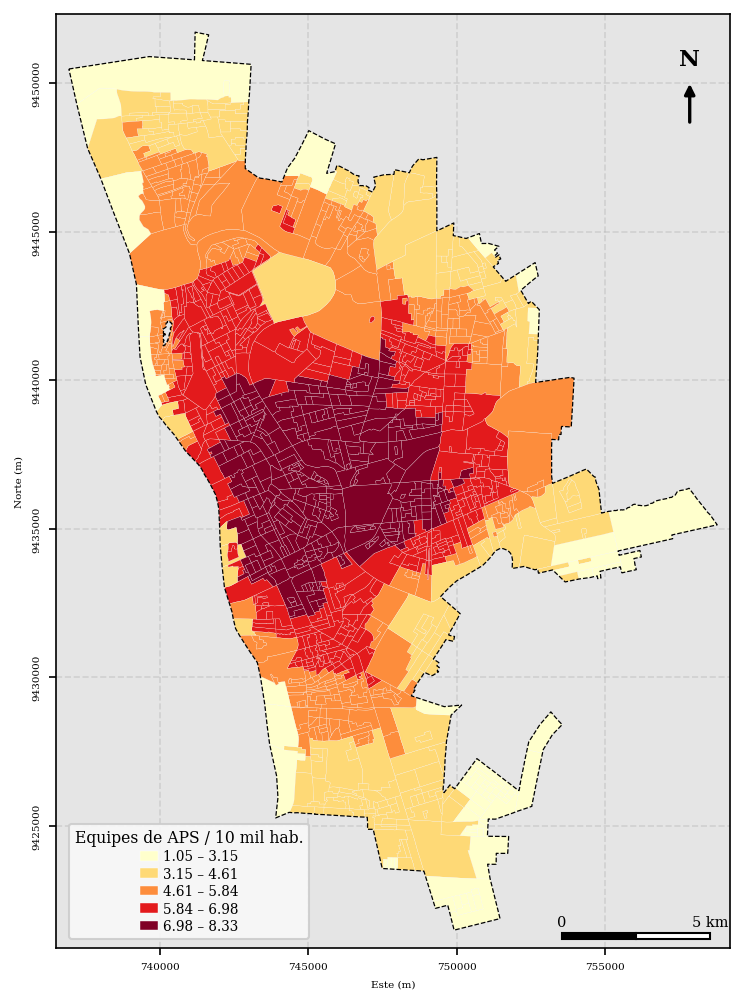

In [6]:
# ── Fig. 01 — Índice AE2SFCA (automóvel) ────────────────────────────────────
setores["acess_carro_10k"] = setores["acess_carro"] * 10_000   # equipes de APS / 10 mil hab

fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")

# classificação NaturalBreaks (k=5) + cor de cada setor = cor da sua classe
classi = mapclassify.NaturalBreaks(setores["acess_carro_10k"].values, k=5)
cmap   = plt.get_cmap("YlOrRd", 5)
setores.plot(ax=ax, color=[cmap(c) for c in classi.yb],
             edgecolor="white", linewidth=0.1, zorder=2)

gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=3)

# legenda em retângulos (Patch), faixas formatadas a partir das quebras
edges = [setores["acess_carro_10k"].min()] + list(classi.bins)
handles = [Patch(facecolor=cmap(i), edgecolor="white", linewidth=0.2,
                 label=f"{edges[i]:.2f} – {edges[i+1]:.2f}") for i in range(5)]
ax.legend(handles=handles, title="Equipes de APS / 10 mil hab.",
          loc="lower left", bbox_to_anchor=(0.01, 0.003),
          fontsize=6.5, title_fontsize=7.5, framealpha=0.9)

ajustar_zoom_camada(ax, setores, margem=0.02)
# moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax, frac_x=0.75, frac_y=0.01); seta_norte(ax)
# fig.savefig(FIGURAS_NB / "nb051_fig01_ae2sfca_carro.png", dpi=300, bbox_inches="tight")
plt.show()

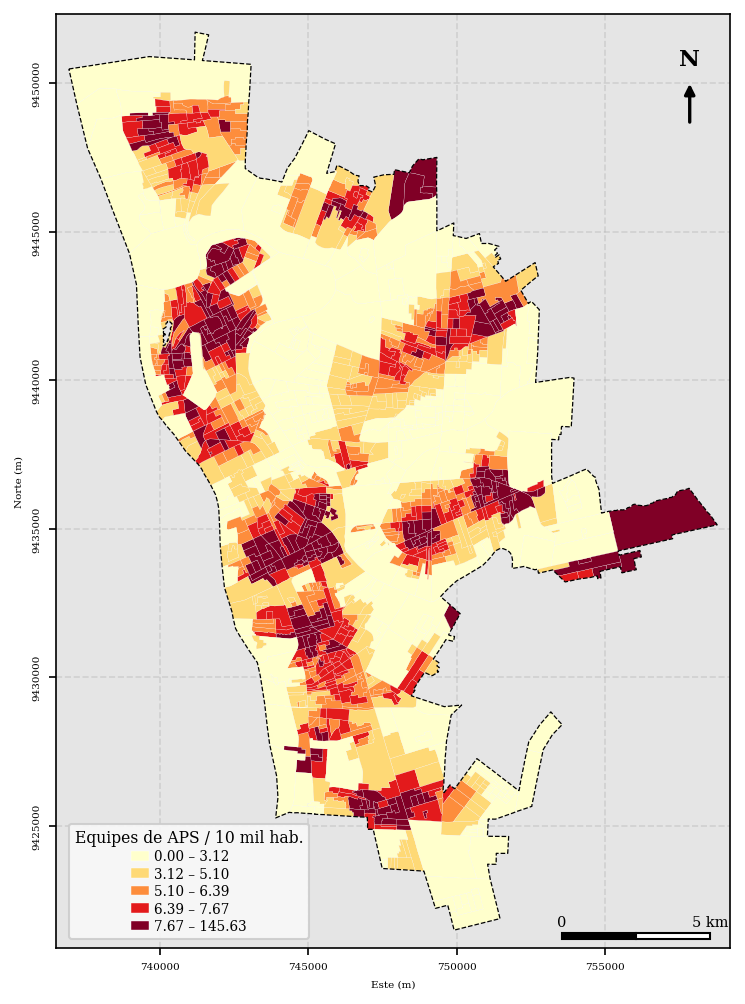

In [7]:
# ── Fig. 01b — Índice AE2SFCA (pedestre) ────────────────────────────────────
setores["acess_pe_10k"] = setores["acess_pe"] * 10_000   # equipes de APS / 10 mil hab

fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")

# classificação NaturalBreaks (k=5) + cor de cada setor = cor da sua classe
classi = mapclassify.Quantiles(setores["acess_pe_10k"].values, k=5)
cmap   = plt.get_cmap("YlOrRd", 5)
setores.plot(ax=ax, color=[cmap(c) for c in classi.yb],
             edgecolor="white", linewidth=0.1, zorder=2)

gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=3)

# legenda em retângulos (Patch), faixas formatadas a partir das quebras
edges = [setores["acess_pe_10k"].min()] + list(classi.bins)
handles = [Patch(facecolor=cmap(i), edgecolor="white", linewidth=0.2,
                 label=f"{edges[i]:.2f} – {edges[i+1]:.2f}") for i in range(5)]
ax.legend(handles=handles, title="Equipes de APS / 10 mil hab.",
          loc="lower left", bbox_to_anchor=(0.01, 0.003),
          fontsize=6.5, title_fontsize=7.5, framealpha=0.9)

ajustar_zoom_camada(ax, setores, margem=0.02)
# moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax, frac_x=0.75, frac_y=0.01); seta_norte(ax)
# fig.savefig(FIGURAS_NB / "nb051_fig01_ae2sfca_pe.png", dpi=300, bbox_inches="tight")
plt.show()

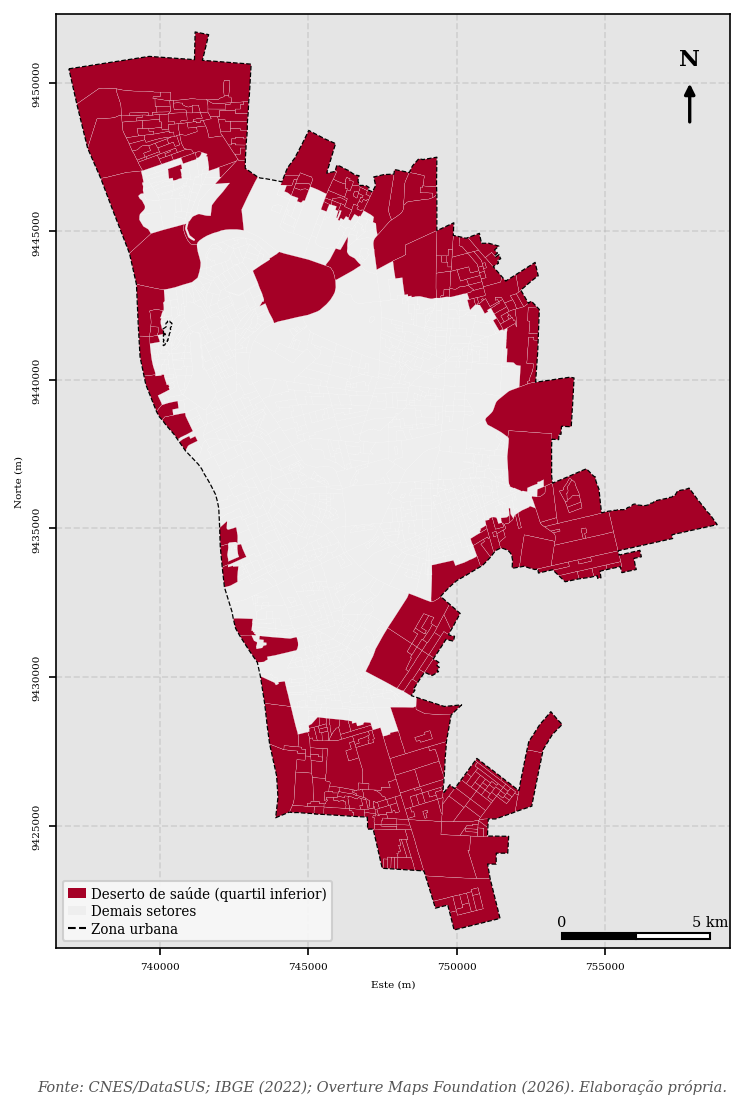

In [8]:
# ── Fig. 02 — Desertos de saúde (modo automóvel) ────────────────────────────
fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
setores.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1, zorder=2)
setores[setores["deserto_carro"]].plot(ax=ax, color="#A50026", edgecolor="white",
                                        linewidth=0.1, zorder=3)
gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=4)
ax.legend(handles=[
    Patch(facecolor="#A50026", label="Deserto de saúde (quartil inferior)"),
    Patch(facecolor="#EEEEEE", label="Demais setores"),
    Line2D([], [], color="black", ls="--", lw=1, label="Zona urbana"),
], loc="lower left", fontsize=6.5, framealpha=0.9)
ajustar_zoom_camada(ax, setores, margem=0.02)
moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax, frac_x=0.75, frac_y=0.01); seta_norte(ax)
# fig.savefig(FIGURAS_NB / "nb051_fig02_desertos_carro_ae2sfca.png", dpi=300, bbox_inches="tight")
plt.show()

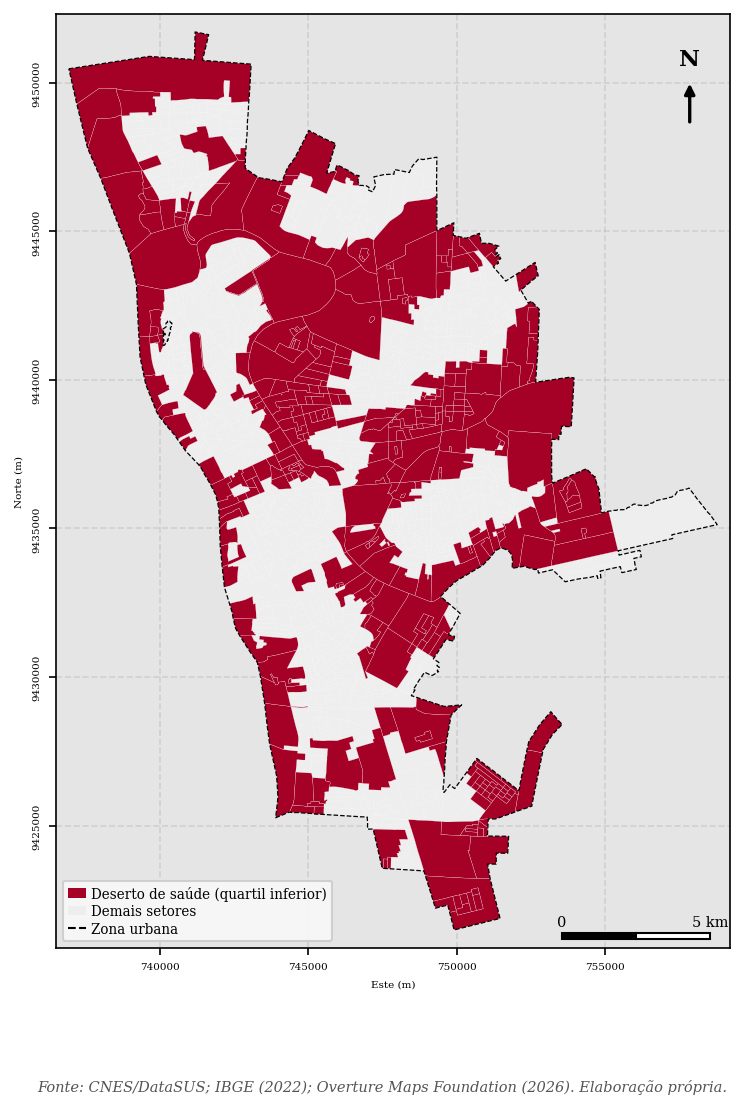

In [9]:
# ── Fig. 02b — Desertos de saúde (modo pedestre) ────────────────────────────
fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
setores.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1, zorder=2)
setores[setores["deserto_pe"]].plot(ax=ax, color="#A50026", edgecolor="white",
                                        linewidth=0.1, zorder=3)
gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=4)
ax.legend(handles=[
    Patch(facecolor="#A50026", label="Deserto de saúde (quartil inferior)"),
    Patch(facecolor="#EEEEEE", label="Demais setores"),
    Line2D([], [], color="black", ls="--", lw=1, label="Zona urbana"),
], loc="lower left", fontsize=6.5, framealpha=0.9)
ajustar_zoom_camada(ax, setores, margem=0.02)
moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax, frac_x=0.75, frac_y=0.01); seta_norte(ax)
# fig.savefig(FIGURAS_NB / "nb051_fig02_desertos_pe_ae2sfca.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Comparação com o E2SFCA tradicional (prévia da H2)

Cálculo do índice por centroide (E2SFCA) nos dois modos e confronto com o areal (Spearman e reclassificação de desertos), base do teste da H2 (consolidado no NB 06.1).

In [10]:
# ── 7. E2SFCA (centroide): índices, desertos e comparação com o AE2SFCA (H1) ─
setores["acess_carro_e2sfca"] = setores["CD_SETOR"].map(
    calcular_e2sfca_centroide(iso_carro, setores, oferta)).fillna(0)
setores["acess_pe_e2sfca"]    = setores["CD_SETOR"].map(
    calcular_e2sfca_centroide(iso_pe,    setores, oferta)).fillna(0)

# desertos E2SFCA no mesmo formato (absoluto + relativo)
for modo in ["carro", "pe"]:
    col = f"acess_{modo}_e2sfca"
    limiar = setores.loc[setores[col] > 0, col].quantile(LIMIAR_QUANTIL)
    setores[f"deserto_{modo}_e2sfca_abs"] = setores[col] == 0
    setores[f"deserto_{modo}_e2sfca_rel"] = (setores[col] > 0) & (setores[col] <= limiar)
    setores[f"deserto_{modo}_e2sfca"]     = (setores[f"deserto_{modo}_e2sfca_abs"]
                                             | setores[f"deserto_{modo}_e2sfca_rel"])

# comparação AE2SFCA × E2SFCA (H2), nos dois modos
for modo in ["carro", "pe"]:
    rho, p = spearmanr(setores[f"acess_{modo}"], setores[f"acess_{modo}_e2sfca"])
    muda = int((setores[f"deserto_{modo}"] != setores[f"deserto_{modo}_e2sfca"]).sum())
    so_a = int(( setores[f"deserto_{modo}"] & ~setores[f"deserto_{modo}_e2sfca"]).sum())
    so_c = int((~setores[f"deserto_{modo}"] &  setores[f"deserto_{modo}_e2sfca"]).sum())
    print(f"H2 ({modo}) — Spearman AE2SFCA×E2SFCA: rho={rho:.3f} (p={p:.1e}) | "
          f"mudam={muda} (só areal={so_a}, só centroide={so_c})")

H2 (carro) — Spearman AE2SFCA×E2SFCA: rho=0.991 (p=0.0e+00) | mudam=23 (só areal=11, só centroide=12)
H2 (pe) — Spearman AE2SFCA×E2SFCA: rho=0.949 (p=0.0e+00) | mudam=78 (só areal=14, só centroide=64)


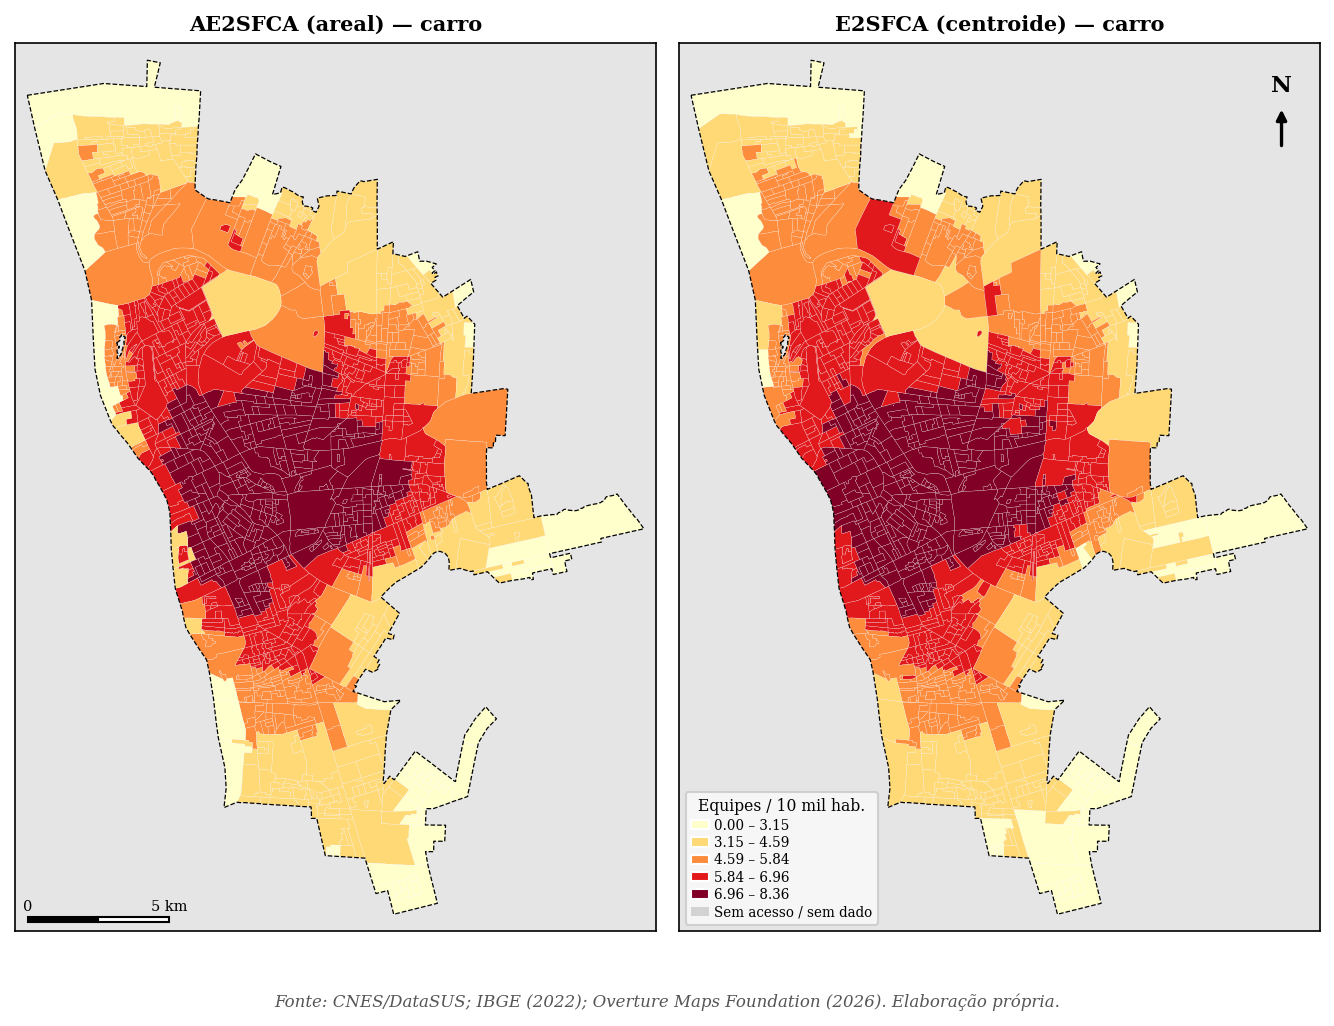

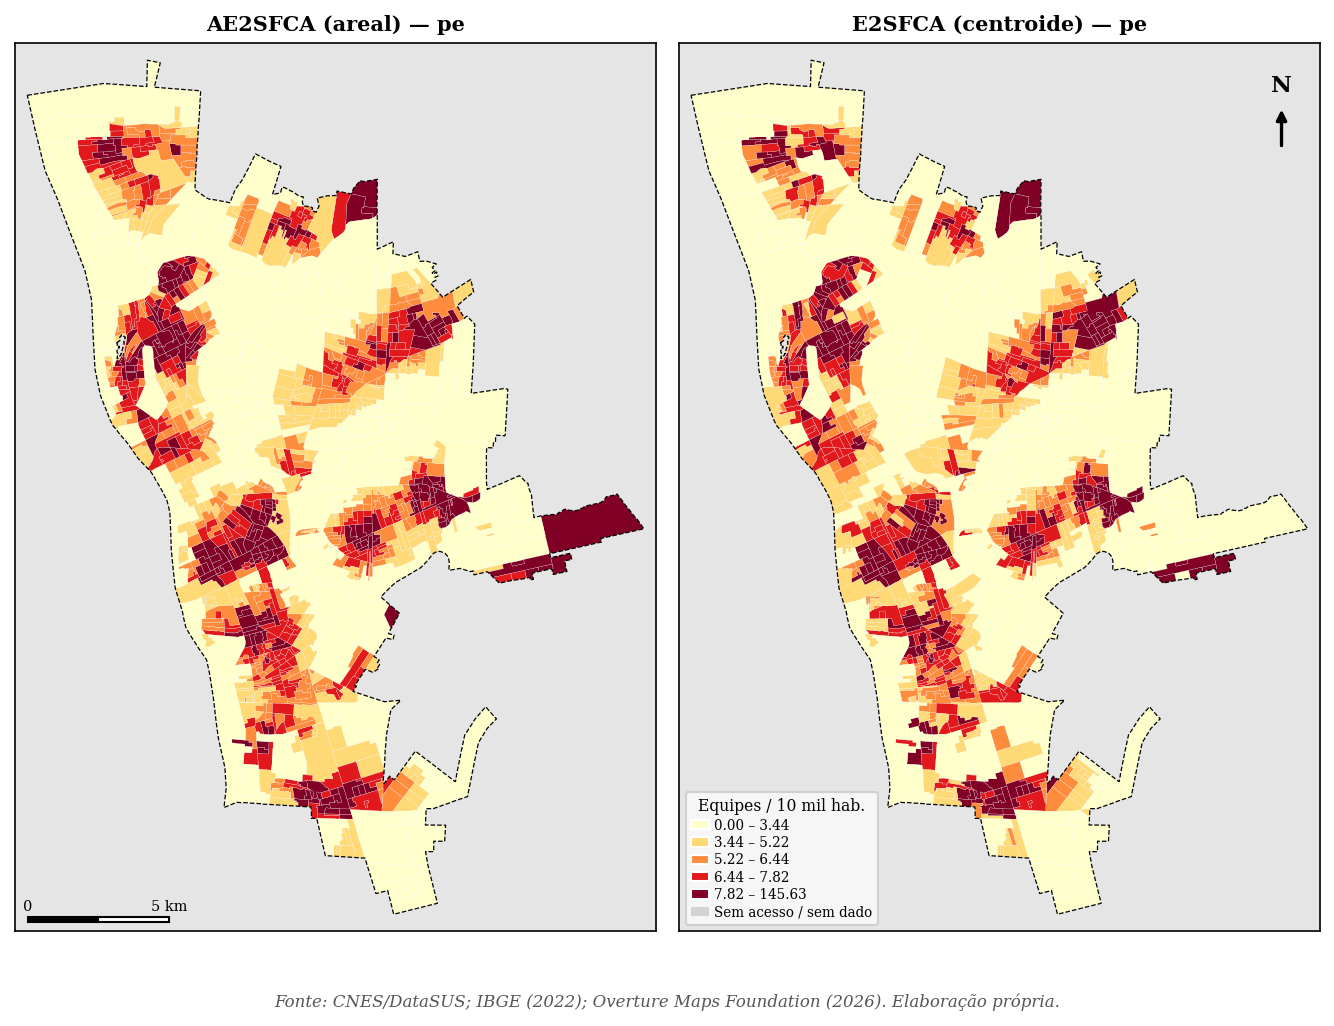

In [ ]:
# ── Fig. 01b — Coropléticos AE2SFCA × E2SFCA, mesma escala de cor ───────────
# Complementa a comparação numérica acima (Spearman, contagem de reclass):
# aqui é visual, mostra a DISTRIBUIÇÃO espacial de cada método lado a lado.

def paineis_metodo(modo, k=5, metodo_classi="NaturalBreaks"):
    """
    1 figura, 2 painéis: AE2SFCA (areal) e E2SFCA (centroide), no modo
    informado ("carro" ou "pe"), com a MESMA classificação de cores.
    """
    col_areal     = f"acess_{modo}"
    col_centroide = f"acess_{modo}_e2sfca"

    # Classificação ÚNICA sobre os valores dos dois métodos combinados —
    # garante que a mesma cor signifique a mesma faixa nos dois painéis.
    valores = pd.concat([setores[col_areal], setores[col_centroide]])
    valores = (valores[valores > 0] * 1e4).values
    classi_geral = (mapclassify.Quantiles(valores, k=k) if metodo_classi == "Quantiles"
                    else mapclassify.NaturalBreaks(valores, k=k))
    bins = classi_geral.bins

    fig, axes = plt.subplots(1, 2, figsize=(9, 7))
    for ax, col, titulo in zip(
        axes, [col_areal, col_centroide],
        [f"AE2SFCA (areal) — {modo}", f"E2SFCA (centroide) — {modo}"]
    ):
        ax.set_facecolor("#E5E5E5")
        setores[f"_{col}_10k"] = setores[col] * 1e4
        setores.plot(
            ax=ax, column=f"_{col}_10k", scheme="UserDefined",
            classification_kwds={"bins": bins},
            cmap="YlOrRd", edgecolor="white", linewidth=0.1, zorder=2,
            missing_kwds={"color": "lightgrey", "label": "Sem acesso / sem dado"},
        )
        gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=3)
        ajustar_zoom_camada(ax, gdf_zu, margem=0.02)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(titulo, fontsize=10, fontweight="bold")

    cmap_obj = plt.get_cmap("YlOrRd", k)
    edges = [0] + list(bins)
    handles = [Patch(facecolor=cmap_obj(i), edgecolor="white",
                     label=f"{edges[i]:.2f} – {edges[i+1]:.2f}") for i in range(k)]
    handles.append(Patch(facecolor="lightgrey", label="Sem acesso / sem dado"))
    axes[1].legend(handles=handles, title="Equipes / 10 mil hab.",
                   loc="lower left", fontsize=6.5, title_fontsize=7.5, framealpha=0.9)

    barra_escala(axes[0]); seta_norte(axes[1])
    fig.text(0.5, 0.02, f"Fonte: {FONTE_PADRAO}", ha="center", fontsize=8,
             style="italic", color="#555")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    fig.savefig(FIGURAS_NB / f"nb051_fig3_ae2sfca_e2sfca_{modo}.png",
                dpi=300, bbox_inches="tight")
    plt.show()

paineis_metodo("carro", metodo_classi="NaturalBreaks")
paineis_metodo("pe",    metodo_classi="Quantiles")

## 8. Síntese cartográfica e estatística

Painel comparativo (isócronas × índice × desertos, por modo) e tabela-síntese das medidas do índice.

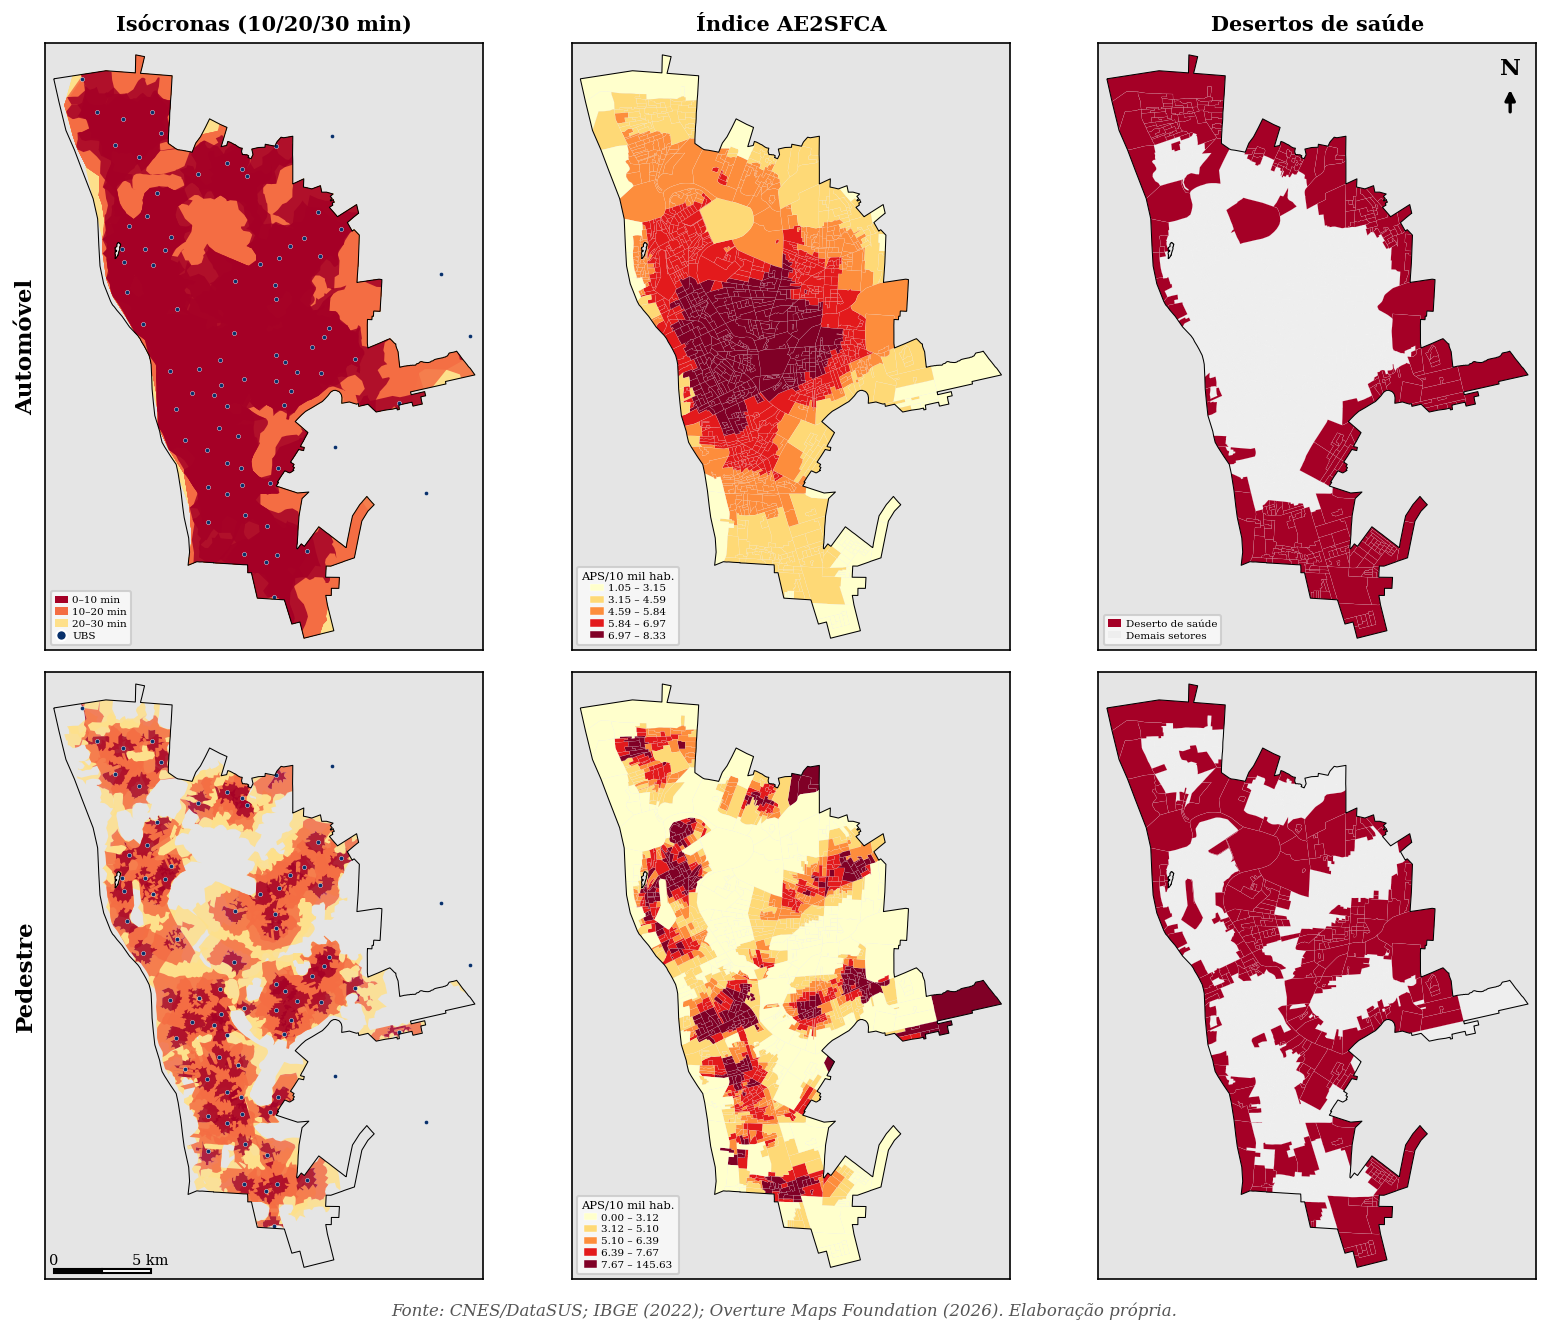

In [12]:
# ── Fig. 03 — Painel comparativo: isócronas × índice × desertos, por modo ────
setores["acess_carro_10k"] = setores["acess_carro"] * 10_000   # caso ainda não exista
setores["acess_pe_10k"]    = setores["acess_pe"]    * 10_000
ubs_pts = ubs_cap.to_crs(CRS_METRICO)

CORES_FAIXA  = {10: "#A50026", 20: "#F46D43", 30: "#FEE08B"}
ROTULO_FAIXA = {10: "0–10 min", 20: "10–20 min", 30: "20–30 min"}

def painel_isocrona(ax, iso):
    ax.set_facecolor("#E5E5E5")
    for limiar in (30, 20, 10):                       # maior por baixo
        faixa = iso[iso["threshold_nominal"] == limiar].clip(gdf_zu)
        if not faixa.empty:
            faixa.plot(ax=ax, color=CORES_FAIXA[limiar], alpha=0.85, linewidth=0)
    ubs_pts.plot(ax=ax, color="#08306B", markersize=4, edgecolor="white", linewidth=0.2)
    gdf_zu.boundary.plot(ax=ax, color="black", lw=0.5)


def painel_indice(ax, col, metodo="NaturalBreaks"):
    ax.set_facecolor("#E5E5E5")
    valores = setores[col].values
    classi = (mapclassify.Quantiles(valores, k=5) if metodo == "Quantiles"
              else mapclassify.NaturalBreaks(valores, k=5))
    cmap = plt.get_cmap("YlOrRd", 5)
    setores.plot(ax=ax, color=[cmap(c) for c in classi.yb], edgecolor="white", linewidth=0.05)
    gdf_zu.boundary.plot(ax=ax, color="black", lw=0.5)
    edges = [valores.min()] + list(classi.bins)
    handles = [Patch(facecolor=cmap(i), edgecolor="white", linewidth=0.2,
                     label=f"{edges[i]:.2f} – {edges[i+1]:.2f}") for i in range(5)]
    ax.legend(handles=handles, loc="lower left", fontsize=5,
              title="APS/10 mil hab.", title_fontsize=5.5, framealpha=0.9)

def painel_deserto(ax, col):
    ax.set_facecolor("#E5E5E5")
    setores.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.05)
    setores[setores[col]].plot(ax=ax, color="#A50026", edgecolor="white", linewidth=0.05)
    gdf_zu.boundary.plot(ax=ax, color="black", lw=0.5)

fig, axes = plt.subplots(2, 3, figsize=(11, 9))
modos = [("Automóvel", iso_carro, "acess_carro_10k", "deserto_carro", "NaturalBreaks"),
         ("Pedestre",  iso_pe,    "acess_pe_10k",    "deserto_pe",    "Quantiles")]
titulos = ["Isócronas (10/20/30 min)", "Índice AE2SFCA", "Desertos de saúde"]

for r, (nome, iso, col_idx, col_des, metodo_idx) in enumerate(modos):
    painel_isocrona(axes[r, 0], iso)
    painel_indice(axes[r, 1], col_idx, metodo_idx)   # ← carro=NaturalBreaks, pé=Quantiles
    painel_deserto(axes[r, 2], col_des)
    axes[r, 0].set_ylabel(nome, fontsize=11, fontweight="bold")   # rótulo da linha (modo)

for c, tit in enumerate(titulos):
    axes[0, c].set_title(tit, fontsize=10, fontweight="bold")     # título da coluna

for ax in axes.flat:                                              # enquadramento comum
    ajustar_zoom_camada(ax, gdf_zu, margem=0.02)
    ax.set_xticks([]); ax.set_yticks([])

# legendas compactas só na linha de cima (categorias idênticas entre modos)
axes[0, 0].legend(handles=[Patch(facecolor=CORES_FAIXA[l], label=ROTULO_FAIXA[l]) for l in (10, 20, 30)]
                  + [Line2D([], [], marker="o", color="#08306B", markeredgecolor="white",
                            lw=0, markersize=5, label="UBS")],
                  loc="lower left", fontsize=5, framealpha=0.9)
axes[0, 2].legend(handles=[Patch(facecolor="#A50026", label="Deserto de saúde"),
                           Patch(facecolor="#EEEEEE", label="Demais setores")],
                  loc="lower left", fontsize=5, framealpha=0.9)

barra_escala(axes[1, 0]); seta_norte(axes[0, 2])
fig.text(0.5, 0.02, f"Fonte: {FONTE_PADRAO}", ha="center", fontsize=8, style="italic", color="#555")
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(FIGURAS_NB / "nb051_fig03_painel_comparativo.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ── Tabela — síntese do índice de acessibilidade ────────────────────────────
def resumo(col):
    s = setores.loc[setores[col] > 0, col] * 10_000   # por 10 mil hab
    return {"n_com_acesso": int((setores[col] > 0).sum()),
            "media": s.mean(), "mediana": s.median(),
            "min": s.min(), "max": s.max(), "cv_pct": s.std()/s.mean()*100}

tab_idx = pd.DataFrame({"automovel": resumo("acess_carro"),
                        "pedestre":  resumo("acess_pe")}).T
tab_idx["n_desertos"] = [int(setores["deserto_carro"].sum()), int(setores["deserto_pe"].sum())]
tab_idx.round(2).to_csv(TABELAS_NB / "nb051_sintese_indice.csv", sep=";", encoding="utf-8-sig")
print(tab_idx.round(2).to_string())

           n_com_acesso  media  mediana   min     max  cv_pct  n_desertos
automovel        1375.0   5.85     6.09  1.05    8.33   25.29         344
pedestre         1357.0   5.62     5.79  0.00  145.63   81.57         358


## 9. Exportação

Grava o GeoDataFrame de acessibilidade por setor (índices, desertos e variantes E2SFCA) para o NB 06.1.

In [14]:
# ── 9. EXPORTAÇÃO ───────────────────────────────────────────────────────────
colunas = ["CD_SETOR", "populacao",
           "acess_carro", "acess_pe", "acess_carro_e2sfca", "acess_pe_e2sfca",
           "deserto_carro", "deserto_carro_abs", "deserto_carro_rel",
           "deserto_pe", "deserto_pe_abs", "deserto_pe_rel",
           "deserto_carro_e2sfca", "deserto_pe_e2sfca", "geometry"]
saida = PROCESSADOS / "teresina_setores_acessibilidade.parquet"
setores[colunas].to_parquet(saida)
print(f"💾 Acessibilidade por setor salva: {saida}")

💾 Acessibilidade por setor salva: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\processados\teresina_setores_acessibilidade.parquet


---
## Próximos passos (NB 06)
- **Teste de H1**: comparar `acess_carro` (areal) × `acess_carro_e2sfca` (centroide) por
  correlação de Spearman e quantificar os setores reclassificados como deserto.
- **Teste de H2**: cruzar `acess_carro`/`acess_pe` com a renda mediana,
  via Spearman e autocorrelação espacial (Moran/LISA, biblioteca `esda`).